# 📊 Exploratory Data Analysis (EDA)

This notebook performs a structured analysis of the diabetes dataset to understand:
- Data distribution
- Feature relationships
- Data quality issues

The goal is to prepare the dataset for preprocessing and modeling.

In [48]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [49]:
df=pd.read_csv("c:\\Users\\HP\\Desktop\\Diabetes-Prediction-System\\data\\diabetes.csv")
print(df.shape)
df.sample(5)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
490,2,83,65.0,28,66.0,36.8,0.629,24,0
320,4,129,60.0,12,231.0,27.5,0.527,31,0
73,4,129,86.0,20,270.0,35.1,0.231,23,0
730,3,130,78.0,23,79.0,28.4,0.323,34,1
417,4,144,82.0,32,169.5,38.5,0.554,37,1


In [44]:
print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.376302,72.194010,29.016927,141.418620,32.335156,0.471876,33.240885,0.348958
std,3.369578,31.084489,12.653032,9.011276,89.465752,7.069896,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.500000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [50]:
df.isnull().sum()



Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation:
No null values present in dataset.
However, this dataset may contain invalid zero values which need investigation.

In [51]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_cols:
    print(f"{col} has {(df[col] == 0).sum()} invalid zero values")

Glucose has 7 invalid zero values
BloodPressure has 18 invalid zero values
SkinThickness has 12 invalid zero values
Insulin has 11 invalid zero values
BMI has 7 invalid zero values


### Insight:
Certain features like BMI, Glucose, etc. cannot realistically be zero.
These should be treated as missing values and handled in preprocessing.

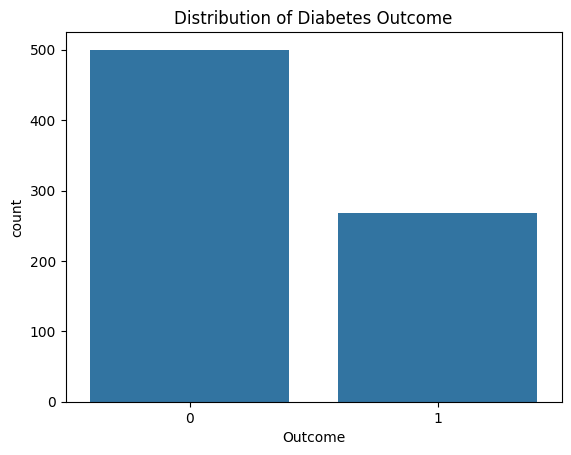

In [52]:
sns.countplot(x="Outcome",data=df)
plt.title("Distribution of Diabetes Outcome")
plt.show()

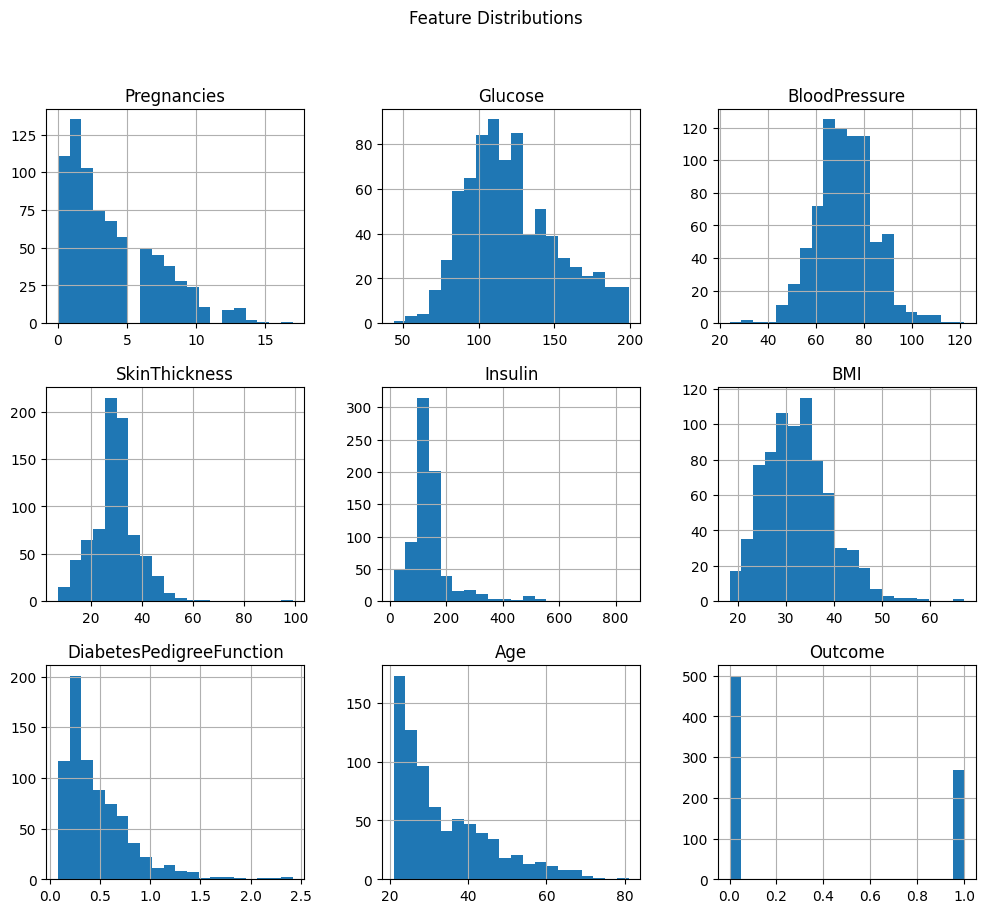

In [35]:
df.hist(bins=20, figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

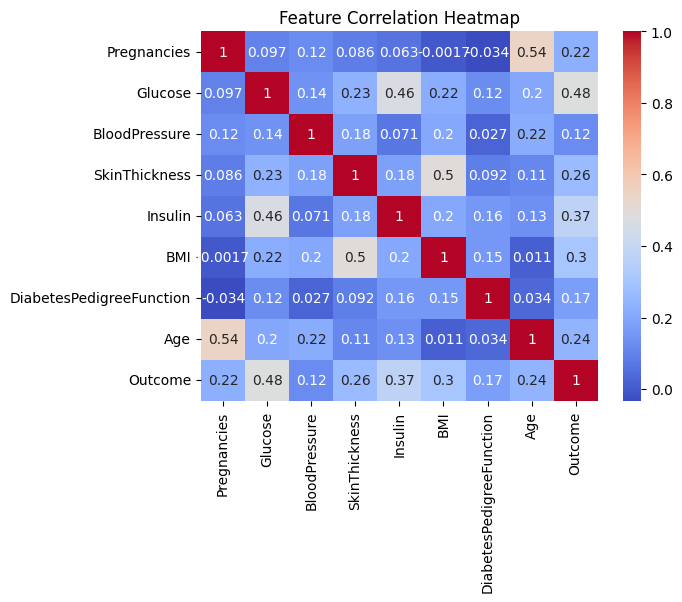

In [53]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### Key Insights:
- Glucose shows strong positive correlation with Outcome
- BMI and Age also have moderate correlation


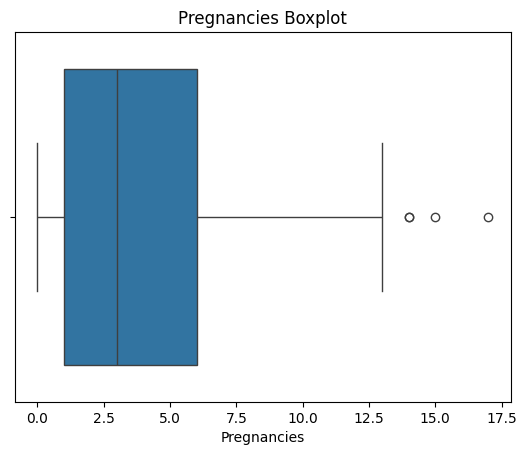

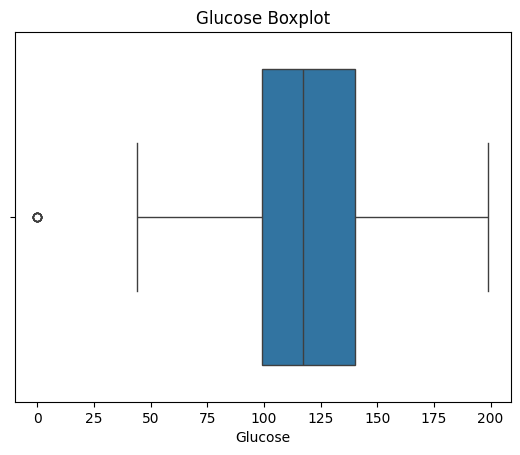

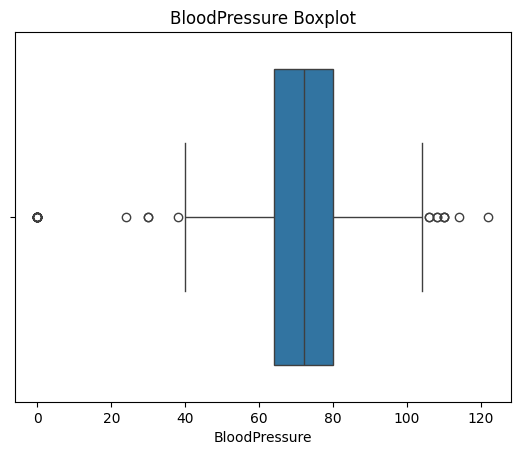

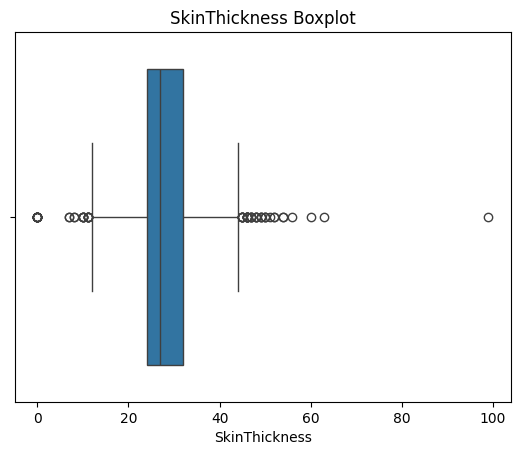

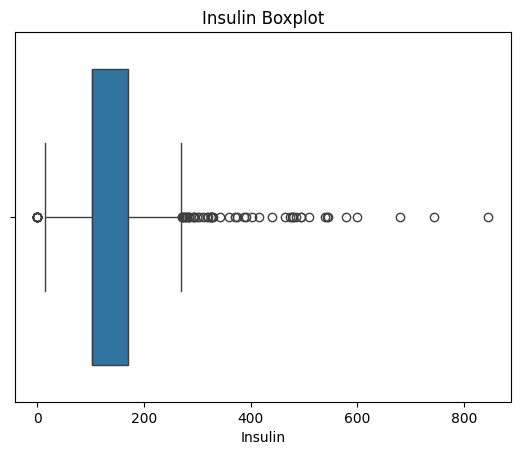

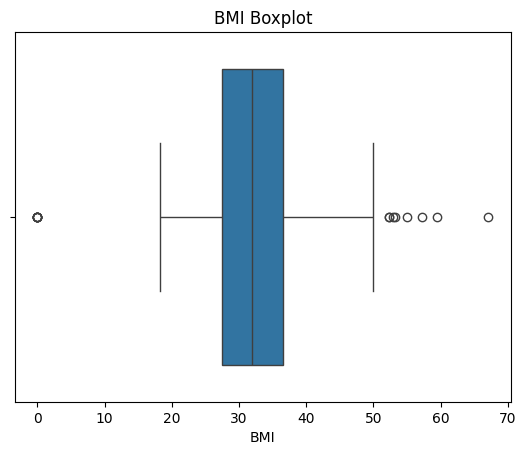

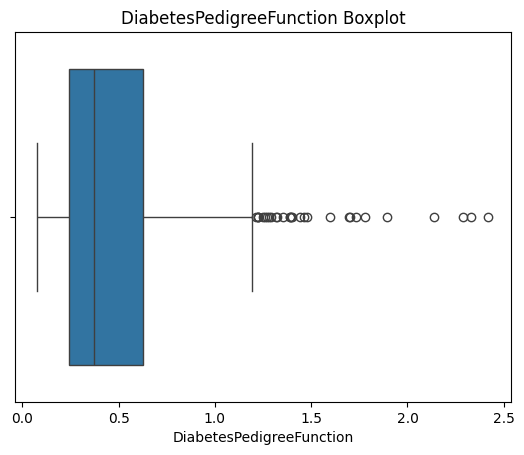

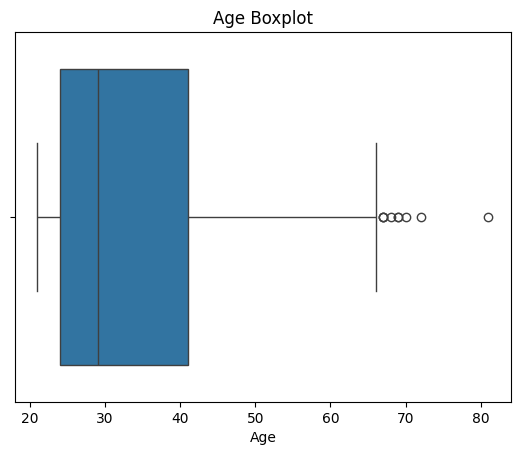

In [54]:
for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()
    

### Observation:
Several features contain outliers which may affect model performance.

## 🧠 Final EDA Summary

- Dataset contains no null values but has invalid zero entries
- Glucose is the most important feature correlated with diabetes
- Dataset is slightly imbalanced
- Outliers are present in multiple features
- Data preprocessing is required before modeling

## 🚀 Next Step
We will:
- Replace invalid zeros with NaN
- Handle missing values
- Apply feature scaling